In [18]:
import pandas as pd 
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

In [4]:
dfm=pd.read_csv(r"C:\Users\SANDESH\Downloads\superstore.csv")

In [5]:
df=dfm.copy()

In [6]:
df.head()

,Order_ID,Order_Date,Category,Sub_Category,Quantity,Sales,Profit,Region
0,1,2025-03-13,Office Supplies,Paper,4,222.55,2.23,East
1,2,2025-01-17,Office Supplies,Binder,7,4471.68,-291.66,East
2,3,2025-04-12,Furniture,Chair,9,1240.04,174.61,South
3,4,2025-03-23,Furniture,Table,1,2987.40,668.50,South
4,5,2025-02-22,Technology,Monitor,6,861.85,243.80,East


In [7]:
df.shape

(200, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      200 non-null    int64  
 1   Order_Date    200 non-null    object 
 2   Category      200 non-null    object 
 3   Sub_Category  200 non-null    object 
 4   Quantity      200 non-null    int64  
 5   Sales         200 non-null    float64
 6   Profit        200 non-null    float64
 7   Region        200 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 12.6+ KB


In [9]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

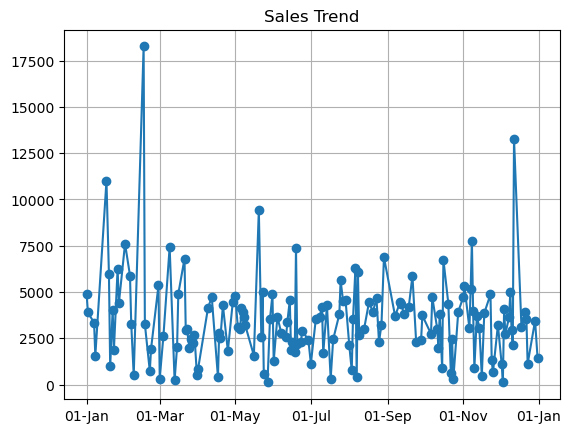

In [19]:
sales_trend = df.groupby("Order_Date")["Sales"].sum()

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%d-%b")
)

plt.plot(
    sales_trend.index,
    sales_trend.values,
    marker="o"
)

plt.title("Sales Trend")
plt.grid(True)

Text(0.5, 1.0, 'Profit Distribution')

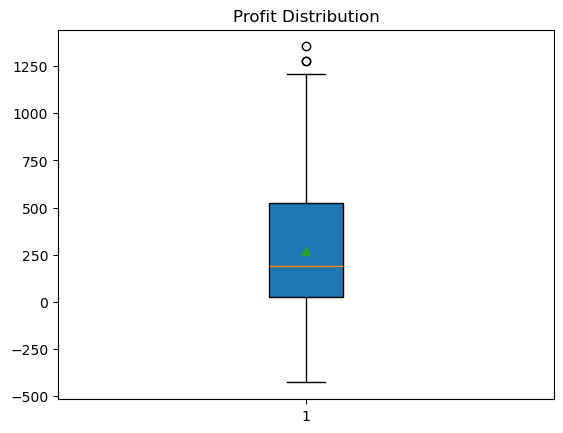

In [25]:
plt.boxplot(
    df["Profit"],
    patch_artist=True,
    showmeans=True
)
plt.title("Profit Distribution")

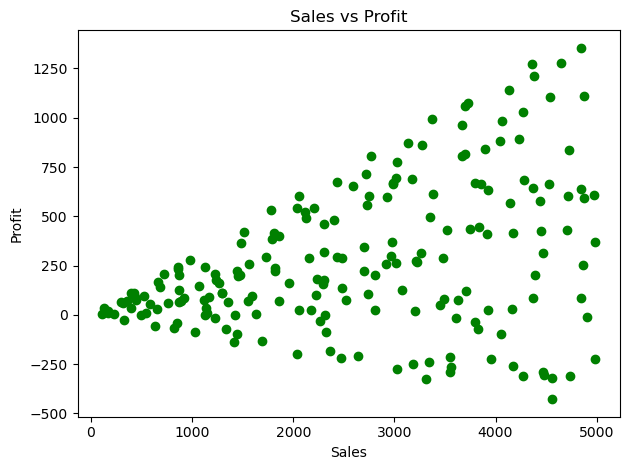

In [23]:
plt.scatter(
    df["Sales"],
    df["Profit"],
    color="g"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Category Sales')

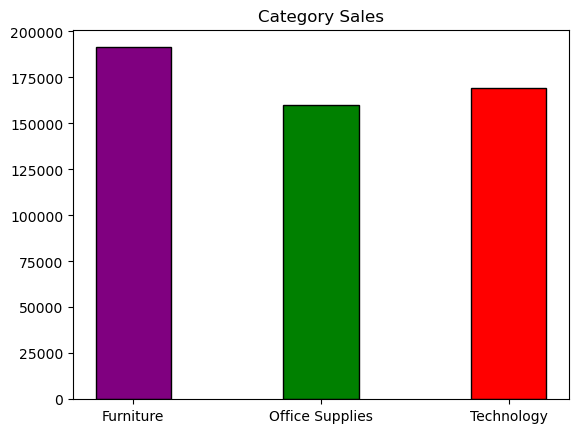

In [45]:
category_sales = df.groupby("Category")["Sales"].sum()



plt.bar(
    category_sales.index,
    category_sales.values,
    edgecolor='black',
    linewidth=1,
    color=["purple", "green", "red"],
    width=0.4
    
)

plt.title("Category Sales")


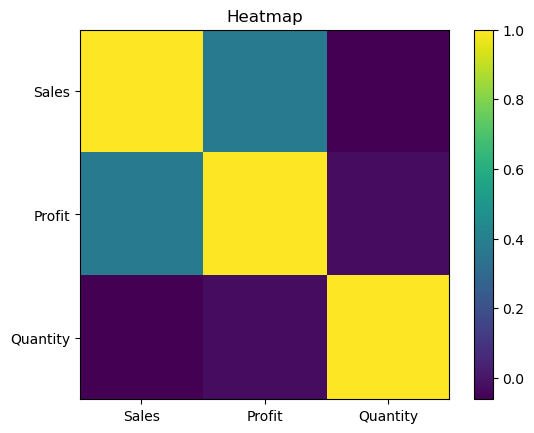

In [52]:
corr = df[["Sales","Profit","Quantity"]].corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Heatmap')
plt.show()

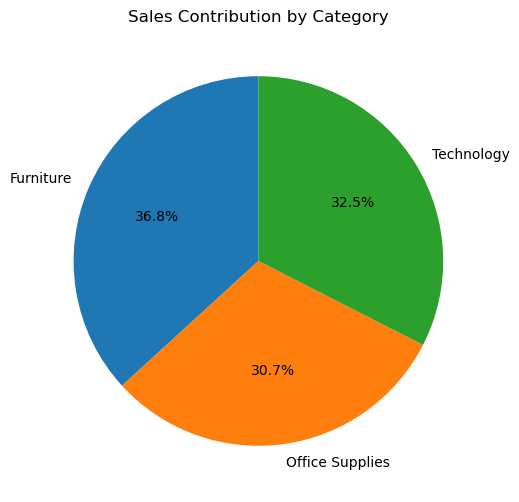

In [51]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,6))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Contribution by Category")

plt.show()